In [2]:
import pandas as pd

def calculate_empirical_probability():
    # Load the datasets
    otos_df = pd.read_excel("otos.xlsx")
    hatos_df = pd.read_excel("hatos.xlsx")
    skandi_df = pd.read_excel("skandinav.xlsx").dropna(subset=['Év', 'Hét'])

    # Define target columns
    year_col = 'Év'
    week_col = 'Hét'

    # Clean year and week columns
    for df in [otos_df, hatos_df, skandi_df]:
        df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
        df[week_col] = pd.to_numeric(df[week_col], errors='coerce')
        
    otos_df = otos_df.dropna(subset=[year_col, week_col])
    hatos_df = hatos_df.dropna(subset=[year_col, week_col])
    skandi_df = skandi_df.dropna(subset=[year_col, week_col])

    # Filter for the last 10 full years (2016 to 2025)
    start_year = 2016
    end_year = 2025

    otos_filtered = otos_df[(otos_df[year_col] >= start_year) & (otos_df[year_col] <= end_year)].copy()
    hatos_filtered = hatos_df[(hatos_df[year_col] >= start_year) & (hatos_df[year_col] <= end_year)].copy()
    skandi_filtered = skandi_df[(skandi_df[year_col] >= start_year) & (skandi_df[year_col] <= end_year)].copy()

    # Ensure target values are numeric
    otos_filtered['Ötös találat'] = pd.to_numeric(otos_filtered['Ötös találat'], errors='coerce').fillna(0)
    hatos_filtered['6 találat (db)'] = pd.to_numeric(hatos_filtered['6 találat (db)'], errors='coerce').fillna(0)
    skandi_filtered['7 találat (db)'] = pd.to_numeric(skandi_filtered['7 találat (db)'], errors='coerce').fillna(0)

    # Helper function to group by Year and Week, and check if a jackpot occurred
    def get_weekly_jackpot_stats(df, hit_column):
        weekly_stats = df.groupby([year_col, week_col])[hit_column].sum().reset_index()
        weekly_stats['has_jackpot'] = (weekly_stats[hit_column] > 0).astype(int)
        return weekly_stats

    # Get weekly distributions
    otos_weekly = get_weekly_jackpot_stats(otos_filtered, 'Ötös találat')
    hatos_weekly = get_weekly_jackpot_stats(hatos_filtered, '6 találat (db)')
    skandi_weekly = get_weekly_jackpot_stats(skandi_filtered, '7 találat (db)')

    # Helper function to calculate and print individual probabilities
    def print_game_stats(weekly_df, game_name):
        total_weeks = len(weekly_df)
        jackpot_weeks = weekly_df['has_jackpot'].sum()
        probability = jackpot_weeks / total_weeks if total_weeks > 0 else 0
        
        print(f"{game_name}:")
        print(f"  Total weeks analyzed: {total_weeks}")
        print(f"  Weeks with at least one jackpot: {jackpot_weeks}")
        print(f"  Empirical probability (P): {probability:.5f} (1 in {total_weeks/jackpot_weeks:.1f} weeks)\n")
        
        return probability

    # Calculate individual probabilities
    p_otos = print_game_stats(otos_weekly, "Ötöslottó")
    p_hatos = print_game_stats(hatos_weekly, "Hatoslottó")
    p_skandi = print_game_stats(skandi_weekly, "Skandináv lottó")

    # Calculate the combined empirical probability
    joint_probability = p_otos * p_hatos * p_skandi
    
    print("-----------")
    print("Combined Joint Probability (Empirical):")
    print(f"  P(combined) = {joint_probability:.8f}")
    print(f"  Expected occurrence: 1 in {1/joint_probability:.1f} weeks")
    print(f"  Which translates to approximately {(1/joint_probability)/52:.2f} years")

if __name__ == "__main__":
    calculate_empirical_probability()

Ötöslottó:
  Total weeks analyzed: 521
  Weeks with at least one jackpot: 41
  Empirical probability (P): 0.07869 (1 in 12.7 weeks)

Hatoslottó:
  Total weeks analyzed: 521
  Weeks with at least one jackpot: 83
  Empirical probability (P): 0.15931 (1 in 6.3 weeks)

Skandináv lottó:
  Total weeks analyzed: 521
  Weeks with at least one jackpot: 163
  Empirical probability (P): 0.31286 (1 in 3.2 weeks)

-----------
Combined Joint Probability (Empirical):
  P(combined) = 0.00392226
  Expected occurrence: 1 in 255.0 weeks
  Which translates to approximately 4.90 years


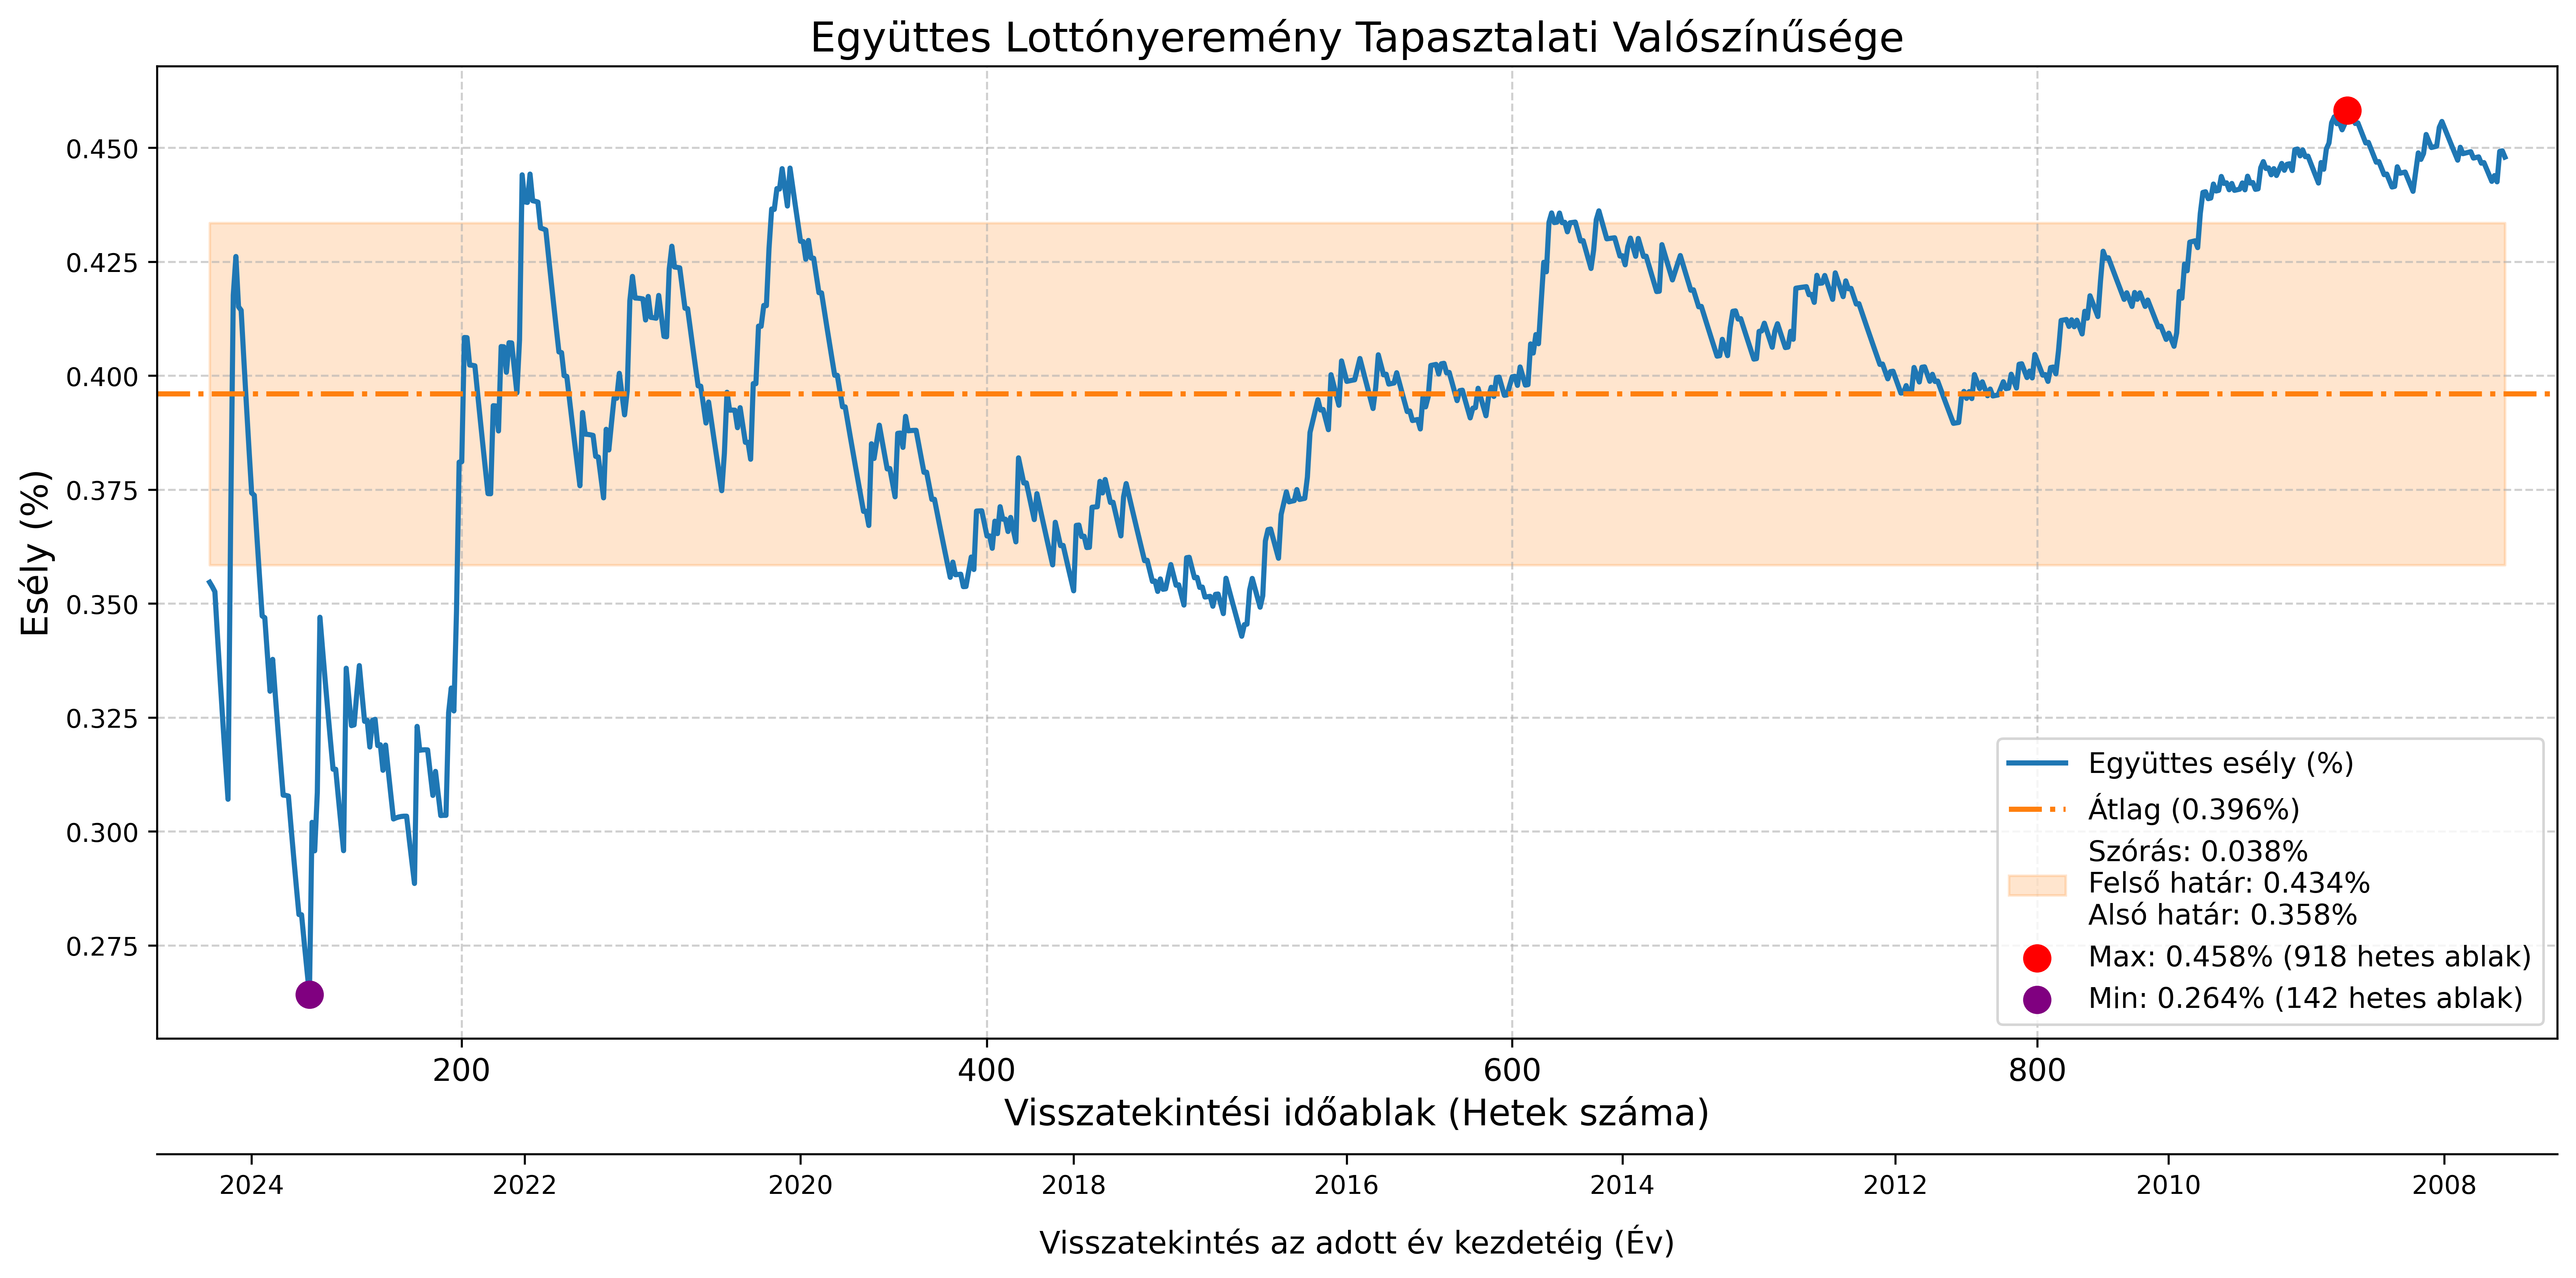

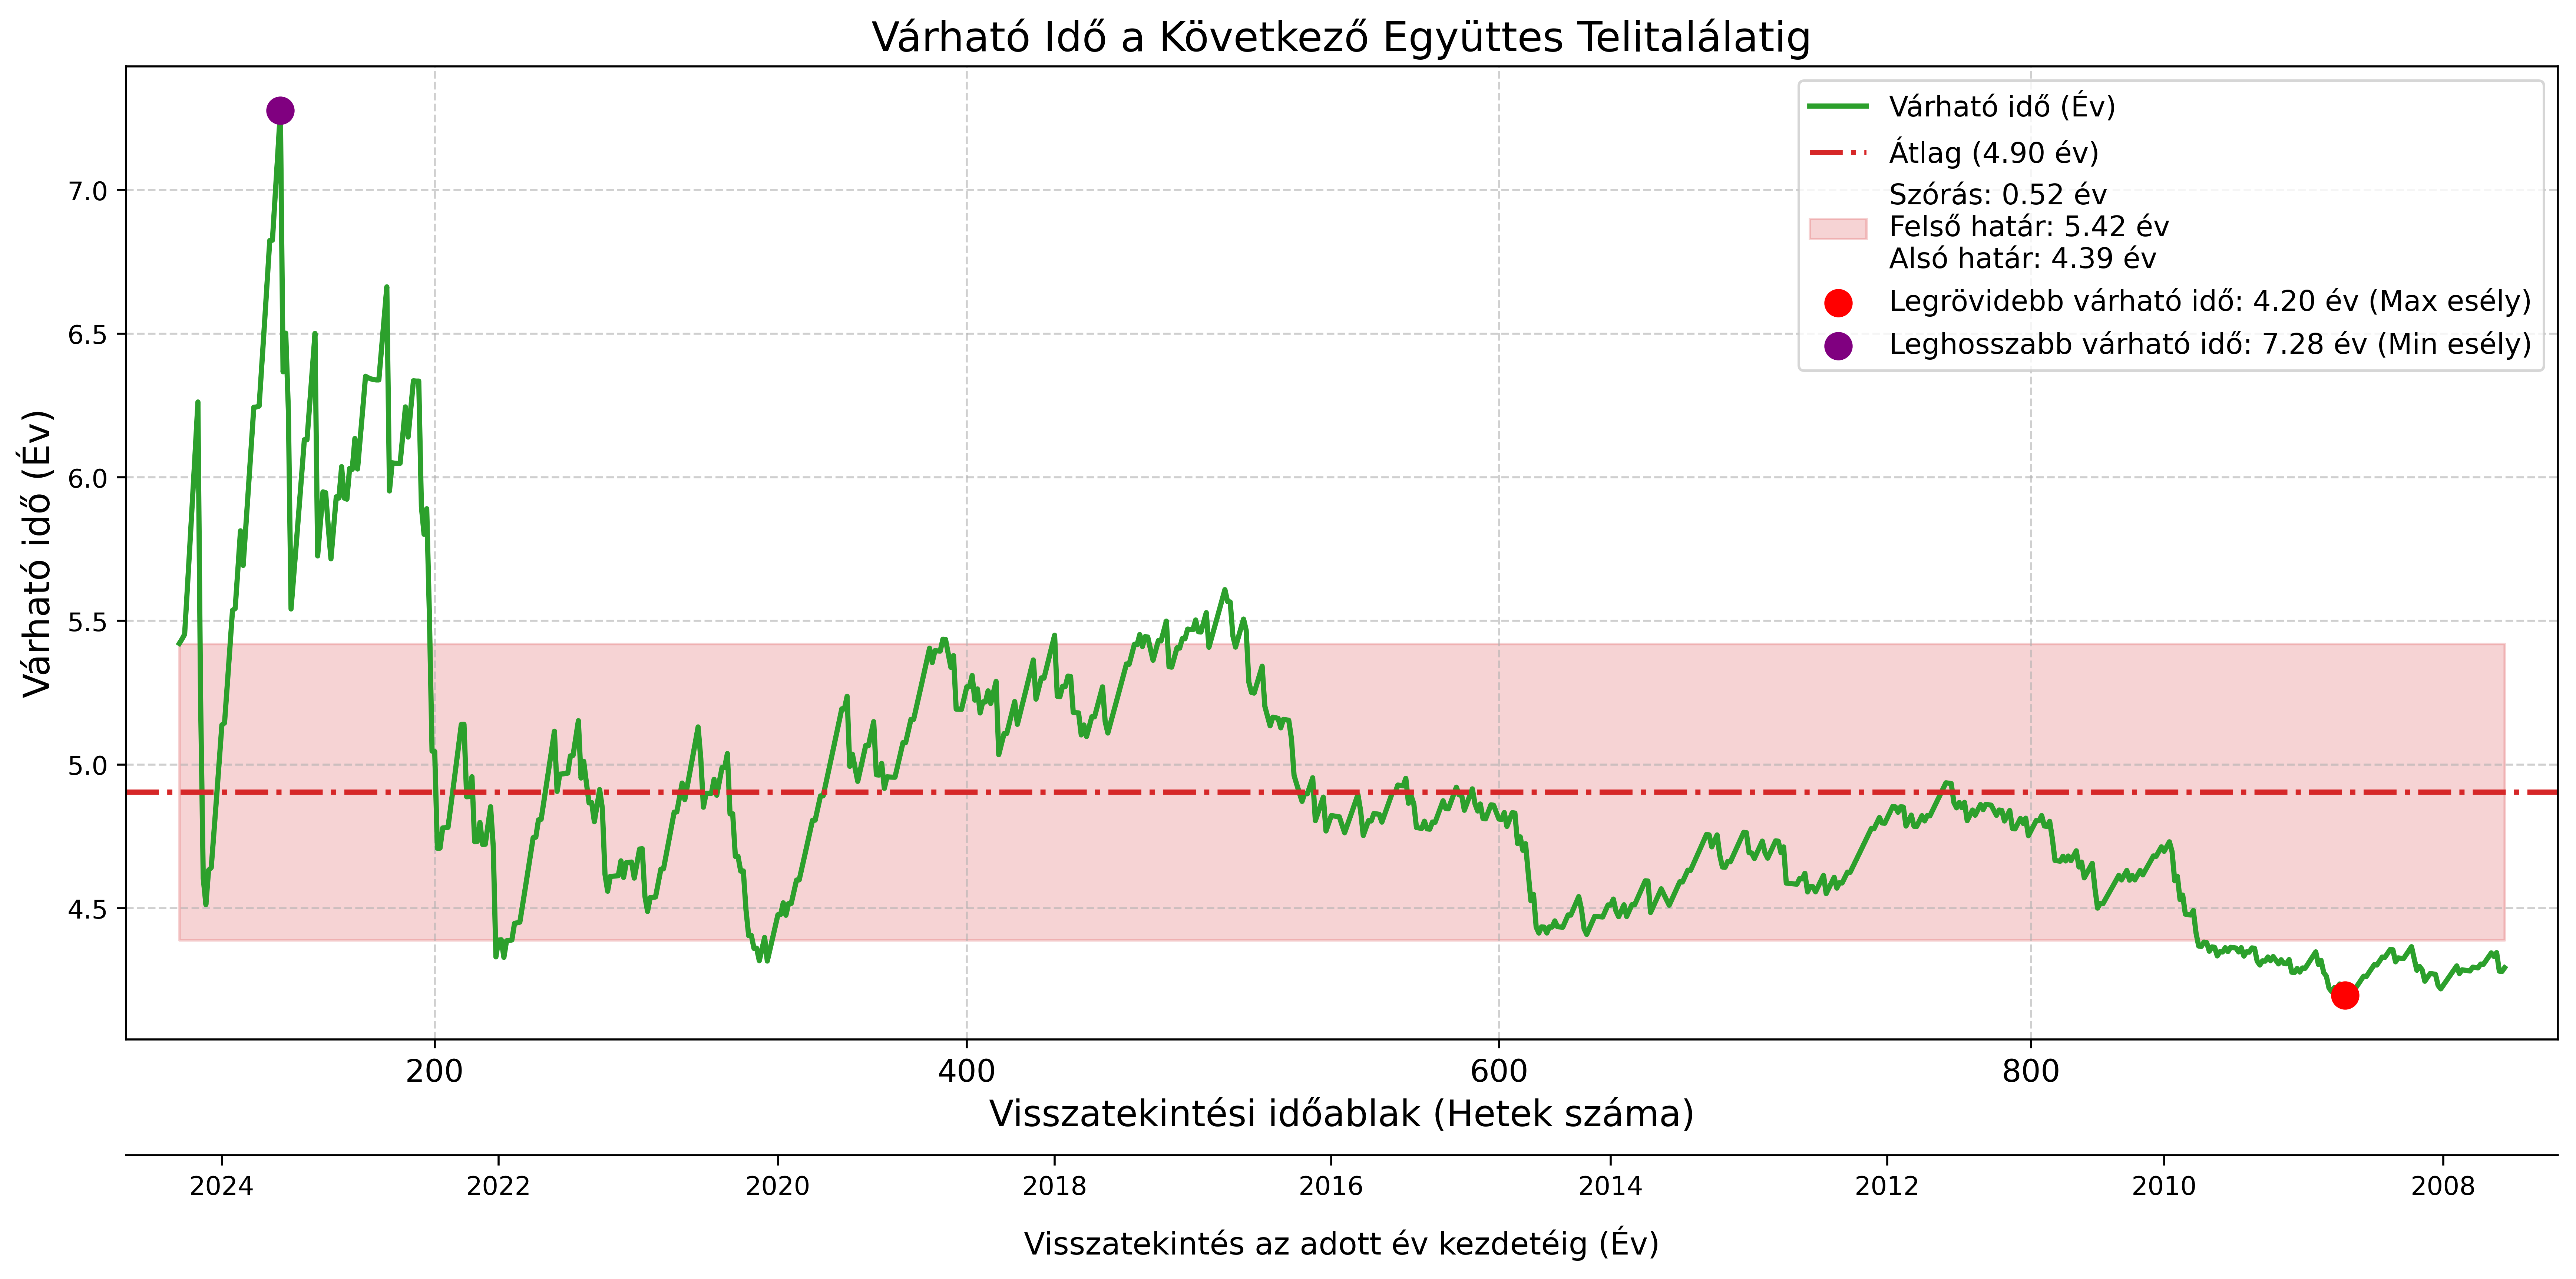

Maximum valószínűség: 0.00458195509966699
Várható évek a maximum valószínűségnél: 4.20
Időpont a maximum valószínűségnél: 2008. W38
Hetek száma az ablakban: 918

-----------

Minimum valószínűség: 0.002642765939018359
Várható évek a minimum valószínűségnél: 7.28
Időpont a minimum valószínűségnél: 2023. W31
Hetek száma az ablakban: 142


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

def run_split_expanding_window_refined():
    # 1. Adatok betöltése
    otos_df = pd.read_excel("otos.xlsx")
    hatos_df = pd.read_excel("hatos.xlsx")
    skandi_df = pd.read_excel("skandinav.xlsx").dropna(subset=['Év', 'Hét'])

    year_col, week_col = 'Év', 'Hét'
    for df in [otos_df, hatos_df, skandi_df]:
        df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
        df[week_col] = pd.to_numeric(df[week_col], errors='coerce')

    otos_df = otos_df.dropna(subset=[year_col, week_col]).copy()
    hatos_df = hatos_df.dropna(subset=[year_col, week_col]).copy()
    skandi_df = skandi_df.dropna(subset=[year_col, week_col]).copy()

    # 2. Szűrés: 2007. 30. hetétől napjainkig
    def filter_timeframe(df):
        return df[(df[year_col] > 2007) | ((df[year_col] == 2007) & (df[week_col] >= 30))].copy()

    o_filt = filter_timeframe(otos_df)
    h_filt = filter_timeframe(hatos_df)
    s_filt = filter_timeframe(skandi_df)

    # 3. Bináris változók
    o_filt['jackpot_hit'] = (pd.to_numeric(o_filt['Ötös találat'], errors='coerce').fillna(0) > 0).astype(int)
    h_filt['jackpot_hit'] = (pd.to_numeric(h_filt['6 találat (db)'], errors='coerce').fillna(0) > 0).astype(int)
    s_filt['jackpot_hit'] = (pd.to_numeric(s_filt['7 találat (db)'], errors='coerce').fillna(0) > 0).astype(int)

    # 4. Heti összesítés
    o_weekly = o_filt.groupby([year_col, week_col])['jackpot_hit'].max().reset_index().rename(columns={'jackpot_hit': 'otos_hit'})
    h_weekly = h_filt.groupby([year_col, week_col])['jackpot_hit'].max().reset_index().rename(columns={'jackpot_hit': 'hatos_hit'})
    s_weekly = s_filt.groupby([year_col, week_col])['jackpot_hit'].max().reset_index().rename(columns={'jackpot_hit': 'skandi_hit'})

    # 5. Egyesítés és kronológiai sorrend (legrégebbi elöl)
    merged_df = o_weekly.merge(h_weekly, on=[year_col, week_col], how='inner').merge(s_weekly, on=[year_col, week_col], how='inner')
    merged_df = merged_df.sort_values(by=[year_col, week_col]).reset_index(drop=True)

    results = []
    total_weeks = len(merged_df)
    
    # 6. Bővülő ablak kiszámítása
    for n in range(104, total_weeks + 1):
        sub_df = merged_df.tail(n)
        p_c = sub_df['otos_hit'].mean() * sub_df['hatos_hit'].mean() * sub_df['skandi_hit'].mean()
        
        start_y = int(sub_df.iloc[0][year_col])
        start_w = int(sub_df.iloc[0][week_col])
        
        results.append({
            'n_weeks': n,
            'start_year': start_y,
            'start_week': start_w,
            'p_combined': p_c,
            'expected_years': 1 / (p_c * 52) if p_c > 0 else None
        })

    results_df = pd.DataFrame(results).dropna()

    # 7. Másodlagos X-tengely (Évek) beállítása
    # A páros évek kezdetét keressük (ahol n_weeks a legnagyobb az adott éven belül)
    even_years_df = results_df[results_df['start_year'] % 2 == 0]
    tick_points = even_years_df.groupby('start_year')['n_weeks'].max().reset_index()
    tick_points = tick_points.sort_values('n_weeks')
    
    sec_tick_x = tick_points['n_weeks'].tolist()
    sec_tick_labels = tick_points['start_year'].astype(str).tolist()

    prim_tick_x = [200, 400, 600, 800, 1000]

    def add_secondary_axis(ax):
        ax_sec = ax.secondary_xaxis('bottom')
        # Kijebb toljuk a tengelyt, hogy elférjen a hetek alatt
        ax_sec.spines['bottom'].set_position(('outward', 45))
        ax_sec.set_xticks(sec_tick_x)
        ax_sec.set_xticklabels(sec_tick_labels)
        ax_sec.tick_params(axis='x', length=4)
        ax_sec.set_xlabel('Visszatekintés az adott év kezdetéig (Év)', fontsize=12, labelpad=10)
        return ax_sec

    # Maximum és Minimum megkeresése
    max_idx = results_df['p_combined'].idxmax()
    min_idx = results_df['p_combined'].idxmin()
    max_row = results_df.loc[max_idx]
    min_row = results_df.loc[min_idx]

    # ==========================================
    # 1. GRAFIKON: EGYÜTTES ESÉLY (%)
    # ==========================================
    fig1, ax1 = plt.subplots(figsize=(14, 7), dpi=500)
    
    mean_p = results_df['p_combined'].mean() * 100
    std_p = results_df['p_combined'].std() * 100
    upper_p = mean_p + std_p
    lower_p = mean_p - std_p
    
    color_p = '#1f77b4'
    
    ax1.plot(results_df['n_weeks'], results_df['p_combined'] * 100, color=color_p, linewidth=2, label='Együttes esély (%)')
    ax1.axhline(mean_p, color='#ff7f0e', linestyle='-.', linewidth=2, label=f'Átlag ({mean_p:.3f}%)')
    
    # Részletes szórás felirat
    std_label = f'Szórás: {std_p:.3f}%\nFelső határ: {upper_p:.3f}%\nAlsó határ: {lower_p:.3f}%'
    ax1.fill_between(results_df['n_weeks'], lower_p, upper_p, color='#ff7f0e', alpha=0.2, label=std_label)

    # Extrémumok jelölése
    ax1.scatter([max_row['n_weeks']], [max_row['p_combined'] * 100], color='red', s=100, zorder=5, 
                label=f"Max: {max_row['p_combined']*100:.3f}% ({int(max_row['n_weeks'])} hetes ablak)")
    ax1.scatter([min_row['n_weeks']], [min_row['p_combined'] * 100], color='purple', s=100, zorder=5, 
                label=f"Min: {min_row['p_combined']*100:.3f}% ({int(min_row['n_weeks'])} hetes ablak)")

    ax1.set_title('Együttes Lottónyeremény Tapasztalati Valószínűsége', fontsize=16)
    ax1.set_xlabel('Visszatekintési időablak (Hetek száma)', fontsize=14)
    ax1.set_ylabel('Esély (%)', fontsize=14)
    
    ax1.set_xticks(prim_tick_x)
    ax1.set_xticklabels([str(x) for x in prim_tick_x], fontsize=12)
    ax1.set_xlim(results_df['n_weeks'].min() - 20, results_df['n_weeks'].max() + 20)
    
    add_secondary_axis(ax1)
    
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='lower right', fontsize=11)
    fig1.tight_layout()
    plt.show()
    fig1.savefig('combined_probability_plot.png', dpi=500)

    # ==========================================
    # 2. GRAFIKON: VÁRHATÓ IDŐ (ÉVEKBEN)
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(14, 7), dpi=500)
    
    mean_y = results_df['expected_years'].mean()
    std_y = results_df['expected_years'].std()
    upper_y = mean_y + std_y
    lower_y = mean_y - std_y
    
    color_y = '#2ca02c'
    
    ax2.plot(results_df['n_weeks'], results_df['expected_years'], color=color_y, linewidth=2, label='Várható idő (Év)')
    ax2.axhline(mean_y, color='#d62728', linestyle='-.', linewidth=2, label=f'Átlag ({mean_y:.2f} év)')
    
    # Részletes szórás felirat
    std_label_y = f'Szórás: {std_y:.2f} év\nFelső határ: {upper_y:.2f} év\nAlsó határ: {lower_y:.2f} év'
    ax2.fill_between(results_df['n_weeks'], lower_y, upper_y, color='#d62728', alpha=0.2, label=std_label_y)

    # Extrémumok jelölése (A Maximum esélyhez tartozik a Minimum várakozási idő!)
    ax2.scatter([max_row['n_weeks']], [max_row['expected_years']], color='red', s=100, zorder=5, 
                label=f"Legrövidebb várható idő: {max_row['expected_years']:.2f} év (Max esély)")
    ax2.scatter([min_row['n_weeks']], [min_row['expected_years']], color='purple', s=100, zorder=5, 
                label=f"Leghosszabb várható idő: {min_row['expected_years']:.2f} év (Min esély)")

    ax2.set_title('Várható Idő a Következő Együttes Telitalálatig', fontsize=16)
    ax2.set_xlabel('Visszatekintési időablak (Hetek száma)', fontsize=14)
    ax2.set_ylabel('Várható idő (Év)', fontsize=14)
    
    ax2.set_xticks(prim_tick_x)
    ax2.set_xticklabels([str(x) for x in prim_tick_x], fontsize=12)
    ax2.set_xlim(results_df['n_weeks'].min() - 20, results_df['n_weeks'].max() + 20)
    
    add_secondary_axis(ax2)
    
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper right', fontsize=11)
    fig2.tight_layout()
    plt.show()
    fig2.savefig('expected_years_plot.png', dpi=500)

    print(f'Maximum valószínűség: {results_df["p_combined"].loc[max_idx]}\nVárható évek a maximum valószínűségnél: {results_df["expected_years"].loc[max_idx]:.2f}\nIdőpont a maximum valószínűségnél: {results_df["start_year"].loc[max_idx]}. W{results_df["start_week"].loc[max_idx]}\nHetek száma az ablakban: {results_df["n_weeks"].loc[max_idx]}')
    print("\n-----------\n")
    print(f'Minimum valószínűség: {results_df["p_combined"].loc[min_idx]}\nVárható évek a minimum valószínűségnél: {results_df["expected_years"].loc[min_idx]:.2f}\nIdőpont a minimum valószínűségnél: {results_df["start_year"].loc[min_idx]}. W{results_df["start_week"].loc[min_idx]}\nHetek száma az ablakban: {results_df["n_weeks"].loc[min_idx]}')


# Execute the analysis
run_split_expanding_window_refined()



In [30]:
import pandas as pd

def check_historical_simultaneous_jackpots():
    # 1. Adatok betöltése
    otos_df = pd.read_excel("otos.xlsx")
    hatos_df = pd.read_excel("hatos.xlsx")
    skandi_df = pd.read_excel("skandinav.xlsx").dropna(subset=['Év', 'Hét'])

    year_col, week_col = 'Év', 'Hét'
    
    # 2. Év és Hét oszlopok tisztítása
    for df in [otos_df, hatos_df, skandi_df]:
        df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
        df[week_col] = pd.to_numeric(df[week_col], errors='coerce')

    otos_df = otos_df.dropna(subset=[year_col, week_col]).copy()
    hatos_df = hatos_df.dropna(subset=[year_col, week_col]).copy()
    skandi_df = skandi_df.dropna(subset=[year_col, week_col]).copy()

    # 3. Bináris változók létrehozása a telitalálatokra
    otos_df['jackpot'] = (pd.to_numeric(otos_df['Ötös találat'], errors='coerce').fillna(0) > 0).astype(int)
    hatos_df['jackpot'] = (pd.to_numeric(hatos_df['6 találat (db)'], errors='coerce').fillna(0) > 0).astype(int)
    skandi_df['jackpot'] = (pd.to_numeric(skandi_df['7 találat (db)'], errors='coerce').fillna(0) > 0).astype(int)

    # 4. Heti adatok aggregálása
    o_weekly = otos_df.groupby([year_col, week_col])['jackpot'].max().reset_index().rename(columns={'jackpot': 'otos_hit'})
    h_weekly = hatos_df.groupby([year_col, week_col])['jackpot'].max().reset_index().rename(columns={'jackpot': 'hatos_hit'})
    s_weekly = skandi_df.groupby([year_col, week_col])['jackpot'].max().reset_index().rename(columns={'jackpot': 'skandi_hit'})

    # 5. Adattáblák egyesítése a közös időszakra (Inner Join)
    merged_df = o_weekly.merge(h_weekly, on=[year_col, week_col], how='inner').merge(s_weekly, on=[year_col, week_col], how='inner')
    
    total_weeks = len(merged_df)
    
    # 6. Azon hetek szűrése, ahol MIndhárom játék értéke 1
    simultaneous_weeks = merged_df[(merged_df['otos_hit'] == 1) & 
                                   (merged_df['hatos_hit'] == 1) & 
                                   (merged_df['skandi_hit'] == 1)]
    
    # 7. Eredmények kiíratása
    print(f"Összes vizsgált közös lottóhét: {total_weeks}")
    print(f"Együttes telitalálatok száma: {len(simultaneous_weeks)}")
    print('\n-----------\n')
    print("\nA pontos dátumok (Év és Hét):")
    print(simultaneous_weeks[[year_col, week_col]].to_string(index=False))
    print("\n-----------\n")
    print(f'Arány: {len(simultaneous_weeks) / total_weeks:.8f}\n(1 a {total_weeks/len(simultaneous_weeks):.0f}-hoz, hetekben)')

check_historical_simultaneous_jackpots()

Összes vizsgált közös lottóhét: 1384
Együttes telitalálatok száma: 8

-----------


A pontos dátumok (Év és Hét):
  Év  Hét
2000   31
2006    9
2007   18
2009   50
2012   39
2018   22
2022    2
2026   16

-----------

Arány: 0.00578035
(1 a 173-hoz, hetekben)
